# Feature Selection Method Comparison

Each section covers one model. Within each section the same train/test split is used to rank features by four methods — SHAP, Gain, LIME, and Information Gain — then evaluates top-k (k = 1…10) features and plots a per-metric comparison.

## Setup

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison


In [181]:
for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")


Modules reloaded.


In [183]:
seed = 999
os.makedirs(f"figures/golub_{seed}", exist_ok=True)
os.makedirs(f"shap_results/golub_{seed}", exist_ok=True)


img_path = f"figures/golub_{seed}"
shap_path = f"shap_results/golub_{seed}"

### Data

In [184]:
golub = pd.read_csv('data/golub.csv')
gene_cols = golub.columns[golub.columns.get_loc('cancer') + 1:]

df = golub.copy()
df["Y"] = df["cancer"].replace({"allB": "ALL", "allT": "ALL", "aml": "AML"})
y = df["Y"].map({"ALL": 0, "AML": 1})

X_raw = df[gene_cols.tolist()].copy()
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=gene_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (57, 7129), Test: (15, 7129)


### Model Wrappers

In [185]:
lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'binary', 'metric': 'average_precision',
        'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31,
        'min_data_in_leaf': 20, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5,
        'verbose': -1, 'seed': seed, 'num_threads': 1,
    },
    num_boost_round=300,
)

scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'eta': 0.05,
    'max_depth': 10,          # much safer
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,   # prevent tiny-leaf splits
    'alpha': 0.1,            # L1 regularization for sparsity
    'scale_pos_weight': scale_pos_weight,
    'max_delta_step': 1,
    },
    num_boost_round=150,
)

rf_wrapper = create_model_wrapper(
    'sklearn', model_class=RandomForestClassifier,
    model_params={'n_estimators': 200, 'random_state': seed, 'max_depth': 20, 'min_samples_leaf': 5},
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={
        'random_seed': seed, 'learning_rate': 0.05, 'depth': 6,
        'eval_metric': 'Logloss', 'iterations': 300,
    },
)

gb_wrapper = create_model_wrapper(
    'sklearn', model_class=GradientBoostingClassifier,
    model_params={
        'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05,
        'subsample': 0.8, 'max_features': 'sqrt', 'random_state': seed,
        'class_weight': 'balanced',
    },
    use_tree_explainer=True,
)

lr_wrapper = create_model_wrapper(
    'sklearn', model_class=LogisticRegression,
    model_params={'random_state': seed, 'max_iter': 1000, 'C': 1.0, 'solver': 'saga'},
    use_linear_explainer=True, use_tree_explainer=False,
)

MODELS = {
    'LightGBM':          lgb_wrapper,
    'XGBoost':           xgb_wrapper,
    'RandomForest':      rf_wrapper,
    'CatBoost':          cb_wrapper,
    'GradientBoosting':  gb_wrapper,
    'LogisticRegression': lr_wrapper,
}

### Helper Functions

In [186]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict_proba(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        p = wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, LightGBMWrapper):
        p = wrapper.model.predict(X)
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict_proba(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        task = 'binary'
        sv = w.compute_shap(X_tr, task=task)
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    X_arr = X_tr.values.astype(float)
    feat_names = X_tr.columns.tolist()
    def _pred(arr, _w=w):
        return _predict_proba(_w, pd.DataFrame(arr, columns=feat_names))
    explainer = LimeTabularExplainer(
        X_arr, feature_names=feat_names,
        class_names=['0', '1'], mode='classification', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[1]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )

def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]  # fixed order

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                proba = _predict_proba(w, X_te[feats])
            p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
            y_pred = (p_pos >= 0.5).astype(int)
            results['accuracy'].append(accuracy_score(y_te, y_pred))
            results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
            results['ap'].append(average_precision_score(y_te, p_pos))
            results['auc'].append(roc_auc_score(y_te, p_pos))
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results


def plot_comparison(model_name, all_results, k_values=list(range(1, 11))):
    metric_keys   = ['accuracy', 'f1',       'ap',                'auc'    ]
    metric_titles = ['Accuracy', 'F1 Score', 'Average Precision', 'AUC-ROC']
    method_styles = {
        'SHAP':   dict(color='steelblue',  linestyle='-',  marker='o'),
        'Gain':   dict(color='darkorange', linestyle='--', marker='s'),
        'MDI':    dict(color='darkorange', linestyle='--', marker='s'),
        'Native': dict(color='darkorange', linestyle='--', marker='s'),
        '|Coef|': dict(color='darkorange', linestyle='--', marker='s'),
        'LIME':   dict(color='green',      linestyle='-.', marker='^'),
        'IG':     dict(color='crimson',    linestyle=':',  marker='D'),
        'Robust': dict(color='purple',     linestyle='-',  marker='X'),
    }
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True)
    for ax, key, title in zip(axes, metric_keys, metric_titles):
        for method, res in all_results.items():
            if res is None:
                continue
            ax.plot(k_values, res[key], linewidth=2.0, markersize=6,
                    label=method, **method_styles.get(method, {}))
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('k (number of features)', fontsize=14)
        ax.set_ylabel(title, fontsize=14)
        ax.set_xticks(k_values)
        ax.tick_params(axis='both', labelsize=11)
        ax.legend(fontsize=10, loc='lower right')
        ax.grid(True, alpha=0.3)
    # fig.suptitle(f'{model_name} — Feature Selection Comparison',
                #  fontsize=15, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"figures/golub_{seed}/golub_{model_name}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

In [187]:
def plot_comparison_bar(model_name, all_results, k_values=list(range(1, 11)), y_min_mean=0.9):
    """Bar chart: one row (4 panels), bars are mean over k with std error bars."""
    metric_keys   = ['accuracy', 'f1',       'ap',                'auc'    ]
    metric_titles = ['Accuracy', 'F1 Score', 'Average Precision', 'AUC-ROC']
    method_colors = {
        'SHAP':   'steelblue',
        'Gain':   'darkorange',
        'MDI':    'darkorange',
        'Native': 'darkorange',
        '|Coef|': 'darkorange',
        'LIME':   'green',
        'IG':     'crimson',
        'RoSHAP': 'purple',
    }

    methods = [m for m, r in all_results.items() if r is not None]
    colors  = [method_colors.get(m, 'gray') for m in methods]
    x       = np.arange(len(methods))
    bar_w   = 0.6

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    for ax, key, title in zip(axes, metric_keys, metric_titles):
        means = [np.nanmean(all_results[m][key]) for m in methods]
        stds  = [np.nanstd(all_results[m][key], ddof=0) for m in methods]

        bars = ax.bar(
            x, means, width=bar_w, color=colors, edgecolor='white', linewidth=0.8,
            yerr=stds, capsize=4,
            error_kw=dict(elinewidth=1.2, ecolor='black', capthick=1.2),
        )
        ax.set_title(title, fontweight='bold', fontsize=22)
        ax.set_ylabel(f'Mean {title}', fontsize=18)
        ax.set_xticks(x)
        ax.set_xticklabels(methods, fontsize=20, rotation=30, ha='right')
        ax.tick_params(axis='y', labelsize=16)
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)

        lower_vals = [m - s for m, s in zip(means, stds)]
        upper_vals = [m + s for m, s in zip(means, stds)]
        y_lo = min(y_min_mean, min(lower_vals) - 0.01)
        y_hi = max(upper_vals) + 0.02
        ax.set_ylim(y_lo, y_hi)

        for bar, m, s in zip(bars, means, stds):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                m + s + (y_hi - y_lo) * 0.01,
                f'{m:.3f}',
                ha='center', va='bottom', fontsize=16,
            )

    plt.tight_layout()
    fig.savefig(f"figures/golub_{seed}/golub_{model_name}_bar_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()


### Information Gain Ranking (computed once, model-agnostic)

In [188]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_classif(X_train, y_train, random_state=42)

ig_ranking = (
    pd.DataFrame({'feature': X_train.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('Top-10 IG features:')
ig_ranking.head(10)


Computing Information Gain scores...
Top-10 IG features:


,feature,importance
0,X95735_at,0.568526
1,M27891_at,0.533469
2,M11722_at,0.530596
3,M23197_at,0.512449
4,L09209_s_at,0.462724
5,M31523_at,0.458843
6,X59417_at,0.451772
7,U46499_at,0.450060
8,M84526_at,0.437362
9,D88270_at,0.422942


---
## LightGBM

### LightGBM — SHAP

In [31]:
print('Computing SHAP ranking for LightGBM...')
lightgbm_shap = get_shap_ranking(MODELS['LightGBM'], X_train, y_train)
print('Top-10:')
lightgbm_shap.head(10)


Computing SHAP ranking for LightGBM...
Top-10:


,feature,importance
0,X95735_at,104.014962
1,M27891_at,67.850363
2,M31523_at,60.497344
3,L09209_s_at,53.214928
4,X62654_rna1_at,39.492400
5,M92287_at,35.021687
6,M23197_at,30.662626
7,M31303_rna1_at,19.616243
8,M62762_at,15.711125
9,M54995_at,14.906108


### LightGBM — Gain

In [32]:
print('Computing Gain ranking for LightGBM...')
lightgbm_gain = get_gain_ranking(MODELS['LightGBM'], X_train, y_train)
if lightgbm_gain is not None:
    print('Top-10:')
    display(lightgbm_gain.head(10))
else:
    print('Gain not supported for LightGBM')


Computing Gain ranking for LightGBM...
Top-10:


,feature,importance
0,X95735_at,175.745024
1,M27891_at,115.145305
2,X62654_rna1_at,90.632272
3,L09209_s_at,87.274319
4,M31523_at,52.960732
5,M92287_at,30.833698
6,X59417_at,26.532729
7,M62762_at,26.269729
8,M31303_rna1_at,24.225224
9,M23197_at,11.076661


### LightGBM — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [33]:
print('Computing LIME ranking for LightGBM...')
lightgbm_lime = get_lime_ranking(
    MODELS['LightGBM'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
lightgbm_lime.head(10)

Computing LIME ranking for LightGBM...
Top-10:


,feature,importance
0,X95735_at,0.178396
1,M27891_at,0.108209
2,L09209_s_at,0.080958
3,M31523_at,0.080795
4,X62654_rna1_at,0.070938
5,M23197_at,0.036957
6,M92287_at,0.033152
7,M62762_at,0.013468
8,M31303_rna1_at,0.008321
9,U72936_s_at,0.008004


### LightGBM — Robust

In [12]:
# first50 = lightgbm_shap['feature'].head(50).tolist()

In [12]:
lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,  # Use preprocessed data with one-hot encoded categoricals
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [07:50<00:00,  2.13it/s]


In [26]:
filepath = shap_path+"/lgb_golub.parquet"
# pd.concat(lgb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath,
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
lgb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(lgb_boot_unscreen)} bootstrap results")

Loaded 1000 bootstrap results


In [27]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [28]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

lightgbm_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
lightgbm_robust.head(10)


,feature,importance
Rank,,
1,M31523_at,11.727636
2,L09209_s_at,6.847078
3,J05243_at,4.149478
4,M23197_at,4.137536
5,M92287_at,1.524242
6,M27891_at,1.401724
7,U46499_at,1.249604
8,X95735_at,0.886343
9,M31303_rna1_at,0.783190


### LightGBM — Evaluation & Comparison

Evaluating LightGBM — SHAP...
Evaluating LightGBM — Gain...
Evaluating LightGBM — LIME...
Evaluating LightGBM — IG...
Evaluating LightGBM — Robust Bootstrap...


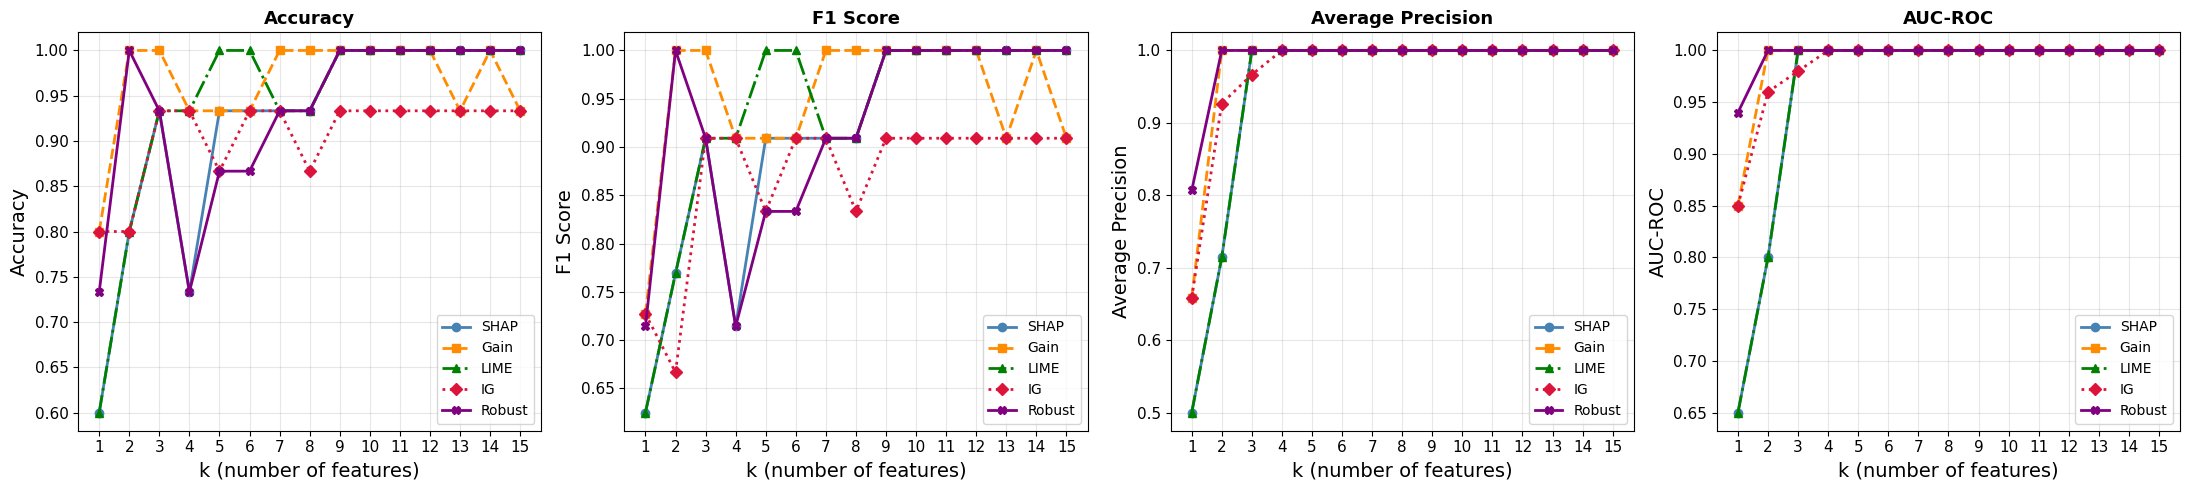

In [29]:
k_values = list(range(1, 16))

print('Evaluating LightGBM — SHAP...')
lightgbm_res_shap = evaluate_topk(MODELS['LightGBM'], lightgbm_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Gain...')
lightgbm_res_gain = evaluate_topk(MODELS['LightGBM'], lightgbm_gain, X_train, X_test, y_train, y_test, k_values) if lightgbm_gain is not None else None

print('Evaluating LightGBM — LIME...')
lightgbm_res_lime = evaluate_topk(MODELS['LightGBM'], lightgbm_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — IG...')
lightgbm_res_ig = evaluate_topk(MODELS['LightGBM'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Robust Bootstrap...')
lightgbm_res_robust = evaluate_topk(MODELS['LightGBM'], lightgbm_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'Robust': lightgbm_res_robust},
    k_values,
)


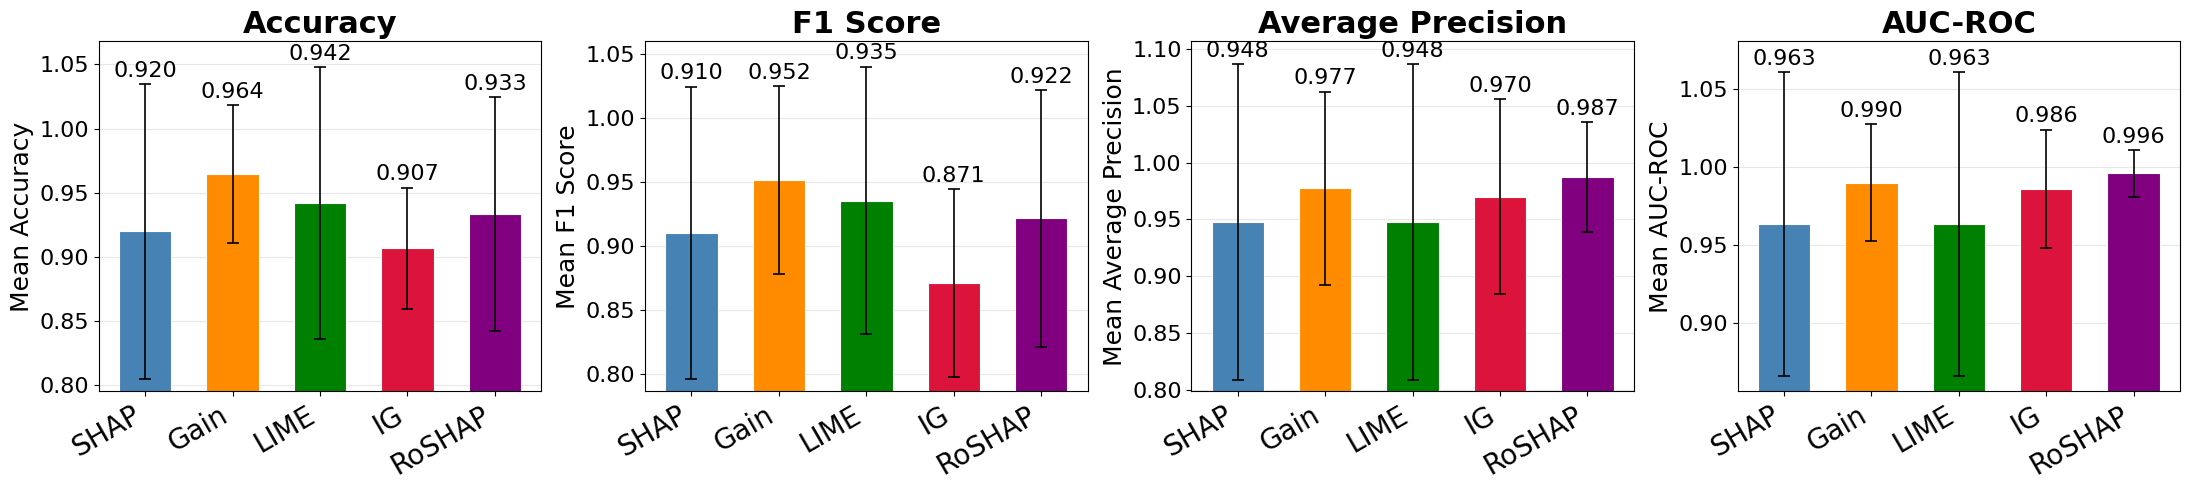

In [30]:
plot_comparison_bar(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'RoSHAP': lightgbm_res_robust},
    k_values,
)

---
## XGBoost

### XGBoost — SHAP

In [189]:
print('Computing SHAP ranking for XGBoost...')
xgboost_shap = get_shap_ranking(MODELS['XGBoost'], X_train, y_train)
print('Top-10:')
xgboost_shap.head(10)

Computing SHAP ranking for XGBoost...
Top-10:


,feature,importance
0,X95735_at,45.019573
1,M27891_at,18.596149
2,M11722_at,12.649557
3,X59417_at,8.021428
4,L09209_s_at,5.631925
5,M84526_at,5.277577
6,M92287_at,4.728599
7,M23197_at,4.701922
8,U46499_at,2.433244
9,HG1612-HT1612_at,2.031010


### XGBoost — Gain

In [190]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train, y_train)
if xgboost_gain is not None:
    print('Top-10:')
    display(xgboost_gain.head(10))
else:
    print('Gain not supported for XGBoost')


Computing Gain ranking for XGBoost...
Top-10:


,feature,importance
0,X95735_at,16.618637
1,M23197_at,14.016426
2,M27891_at,13.542411
3,L09209_s_at,12.993408
4,M11722_at,12.406717
5,M84526_at,11.901730
6,X59417_at,10.722617
7,U46499_at,6.497930
8,M92287_at,6.130381
9,HG1612-HT1612_at,4.341454


### XGBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [191]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
xgboost_lime.head(10)


Computing LIME ranking for XGBoost...
Top-10:


,feature,importance
0,X95735_at,0.168010
1,M27891_at,0.048367
2,M11722_at,0.031564
3,X59417_at,0.030861
4,M84526_at,0.008947
5,V00542_f_at,0.004045
6,L09209_s_at,0.003994
7,Z50115_s_at,0.003976
8,X17567_s_at,0.003830
9,M61855_at,0.003795


### XGBoost — Robust

In [192]:
# first50 = xgboost_shap['feature'].head(50).tolist()

In [193]:
xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=100,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=xgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 100/100 [01:32<00:00,  1.09it/s]


In [ ]:
filepath = shap_path+"/xgb_golub.parquet"
pd.concat(xgb_boot_unscreen, ignore_index=True).to_parquet(
    filepath,
    index=False,
    compression="zstd"
)
print("Saved!")

df_all = pd.read_parquet(filepath)
xgb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(xgb_boot_unscreen)} bootstrap results")

Saved!
Loaded 500 bootstrap results


In [194]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [195]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

xgboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
xgboost_robust.head(10)


,feature,importance
Rank,,
1,X95735_at,6.067092
2,M27891_at,0.675542
3,M11722_at,0.339392
4,L09209_s_at,0.273443
5,AC000064_cds1_at,0.000000
6,D13628_at,0.000000
7,D13630_at,0.000000
8,D14658_at,0.000000
9,D14664_at,0.000000


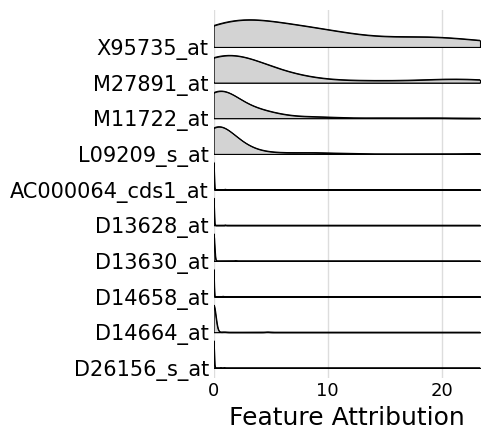

In [196]:
top_k = 10
agg_col = "sum_abs_shap"
top_features = xgboost_robust["feature"].astype(str).head(top_k).tolist()

box_rows = []
for b, res in enumerate(xgb_boot_unscreen):
    part = res.loc[:, ["feature", agg_col]].copy()
    part["feature"] = part["feature"].astype(str)
    part = part[part["feature"].isin(top_features)]
    part["bootstrap_id"] = b
    box_rows.append(part)

box_df = pd.concat(box_rows, ignore_index=True)
box_df = box_df.dropna(subset=[agg_col])
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plot_data = [
    box_df.loc[box_df["feature"] == f, agg_col].dropna().to_numpy()
    for f in top_features
]

all_vals = np.concatenate(plot_data)
x_min = np.nanpercentile(all_vals, 0.1)
x_max = np.nanpercentile(all_vals, 99)
x_grid = np.linspace(x_min, x_max, 500)

spacing = 0.55
scale = 0.42

fig, ax = plt.subplots(figsize=(5, max(4.5, 0.38 * len(top_features))))

ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#DDDDDD", linewidth=1.0, zorder=0)

for i in range(len(top_features)):
    feature = top_features[i]
    vals = plot_data[i]
    y_base = (len(top_features) - 1 - i) * spacing

    if len(vals) > 2 and np.std(vals) > 0:
        kde = gaussian_kde(vals)
        dens = kde(x_grid)
        dens = dens / dens.max() * scale
    else:
        dens = np.zeros_like(x_grid)

    ax.fill_between(
        x_grid,
        y_base,
        y_base + dens,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.8,
        alpha=1.0,
        zorder=10 + i,
    )

    ax.plot(
        x_grid,
        y_base + dens,
        color="black",
        linewidth=0.8,
        zorder=11 + i,
    )

    ax.hlines(
        y_base,
        x_min,
        x_max,
        color="black",
        linewidth=0.5,
        zorder=12 + i,
    )

ax.set_yticks([(len(top_features) - 1 - i) * spacing for i in range(len(top_features))])
ax.set_yticklabels(top_features, fontsize=13)

ax.set_xlabel(r"Feature Attribution", fontsize=18)
ax.set_ylabel("")

ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.15, (len(top_features) - 1) * spacing + scale + 0.15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", labelsize=13, length=0)
ax.tick_params(axis="y", labelsize=15, length=0)

plt.tight_layout()
plt.show()

### XGBoost — Evaluation & Comparison

Evaluating XGBoost — SHAP...
Evaluating XGBoost — Gain...
Evaluating XGBoost — LIME...
Evaluating XGBoost — IG...
Evaluating XGBoost — Robust Bootstrap...


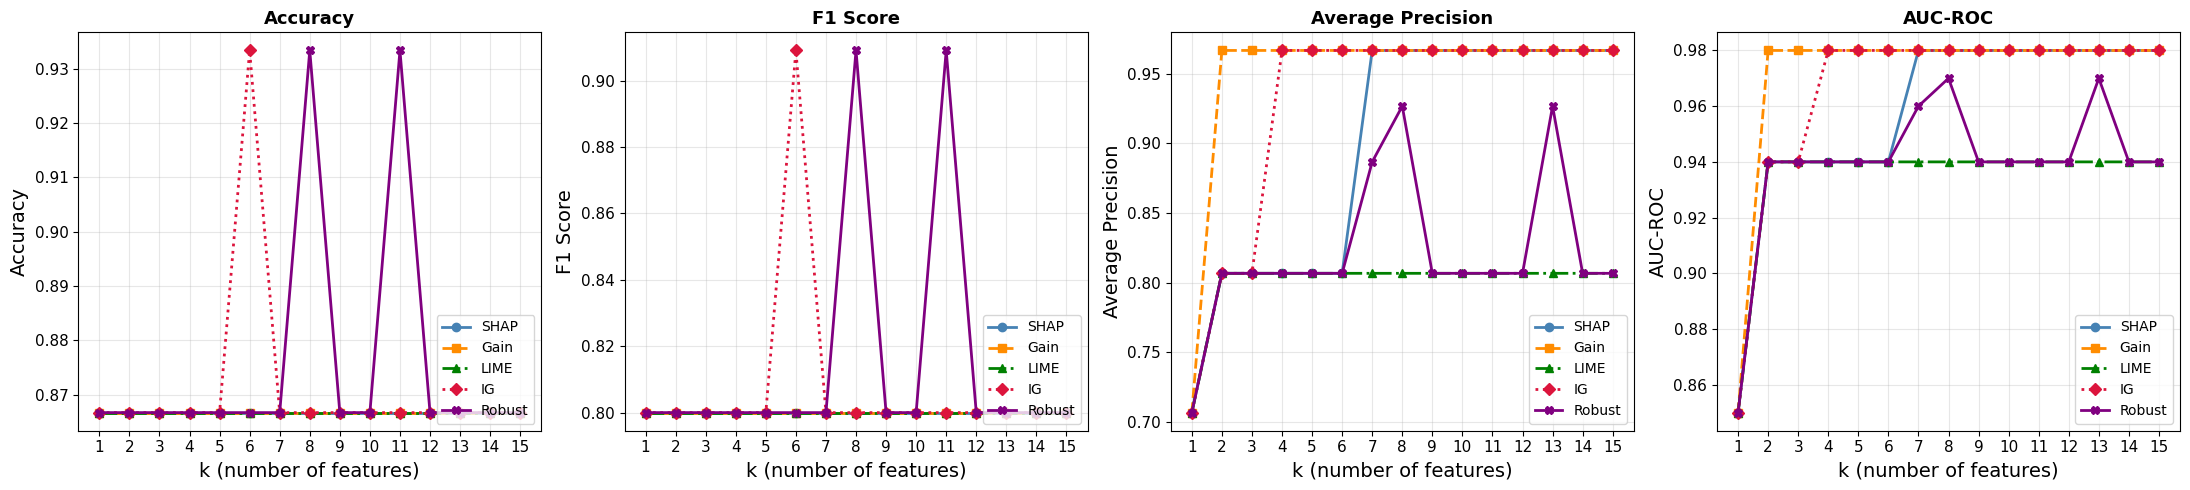

In [197]:
k_values = list(range(1, 16))

print('Evaluating XGBoost — SHAP...')
xgboost_res_shap = evaluate_topk(MODELS['XGBoost'], xgboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Gain...')
xgboost_res_gain = evaluate_topk(MODELS['XGBoost'], xgboost_gain, X_train, X_test, y_train, y_test, k_values) if xgboost_gain is not None else None

print('Evaluating XGBoost — LIME...')
xgboost_res_lime = evaluate_topk(MODELS['XGBoost'], xgboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — IG...')
xgboost_res_ig = evaluate_topk(MODELS['XGBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Robust Bootstrap...')
xgboost_res_robust = evaluate_topk(MODELS['XGBoost'], xgboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'XGBoost',
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain,
     'LIME': xgboost_res_lime, 'IG':   xgboost_res_ig, 'Robust': xgboost_res_robust},
    k_values,
)


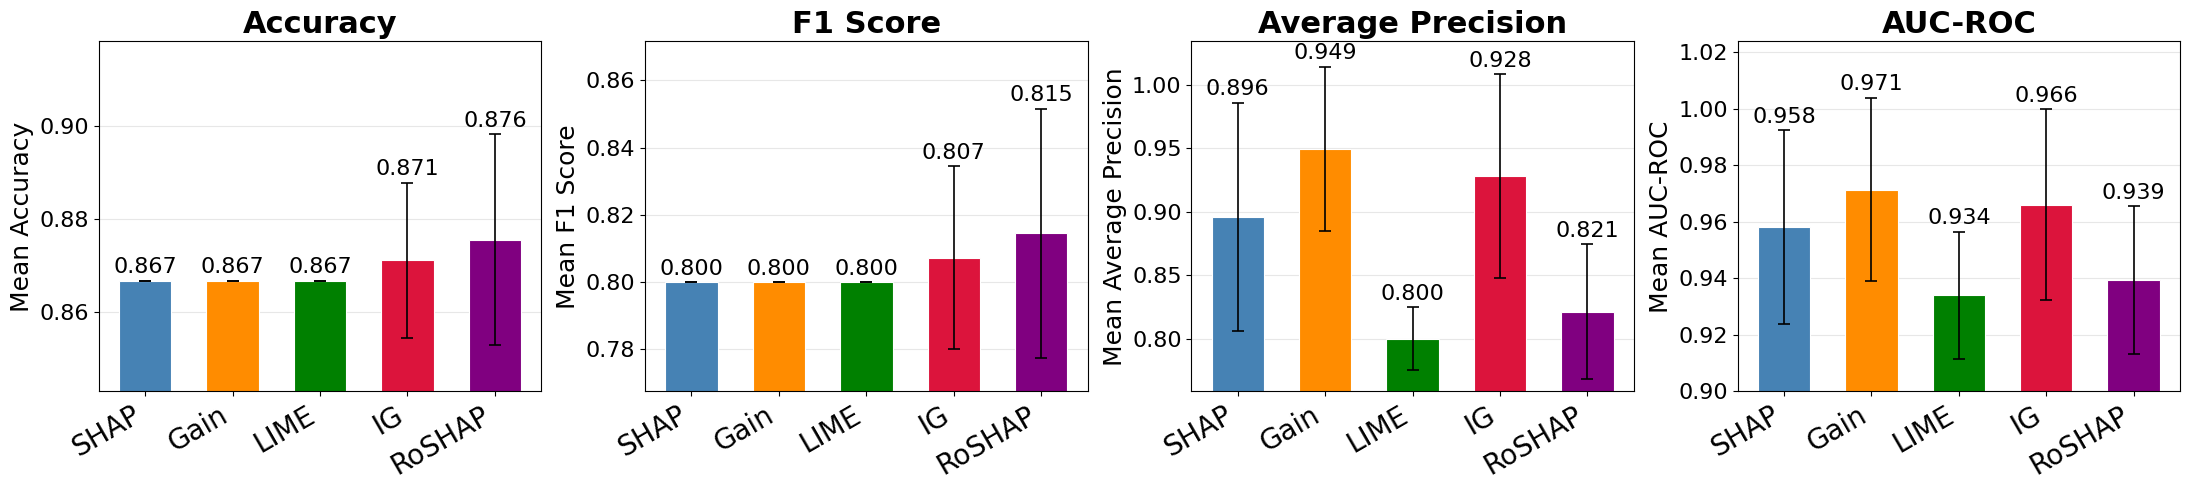

In [198]:
plot_comparison_bar(
    'XGBoost', 
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain, 
     'LIME': xgboost_res_lime, 'IG': xgboost_res_ig, 'RoSHAP': xgboost_res_robust}, k_values
)

---
## RandomForest

### RandomForest — SHAP

In [31]:
print('Computing SHAP ranking for RandomForest...')
randomforest_shap = get_shap_ranking(MODELS['RandomForest'], X_train, y_train)
print('Top-10:')
randomforest_shap.head(10)


Computing SHAP ranking for RandomForest...
Top-10:


,feature,importance
0,J05243_at,0.680625
1,M62762_at,0.492034
2,U97105_at,0.482114
3,X62654_rna1_at,0.438332
4,X95735_at,0.388521
5,U29175_at,0.358484
6,M11722_at,0.318835
7,X62320_at,0.291181
8,U46499_at,0.290151
9,M14636_at,0.285836


### RandomForest — Gain

In [32]:
print('Computing Gain ranking for RandomForest...')
randomforest_gain = get_gain_ranking(MODELS['RandomForest'], X_train, y_train)
if randomforest_gain is not None:
    print('Top-10:')
    display(randomforest_gain.head(10))
else:
    print('Gain not supported for RandomForest')


Computing Gain ranking for RandomForest...
Top-10:


,feature,importance
0,J05243_at,0.027254
1,M62762_at,0.023419
2,U97105_at,0.021081
3,X62654_rna1_at,0.018645
4,U29175_at,0.016931
5,X95735_at,0.016302
6,X62320_at,0.013300
7,M11722_at,0.012761
8,M14636_at,0.012192
9,U46499_at,0.012039


### RandomForest — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [33]:
print('Computing LIME ranking for RandomForest...')
randomforest_lime = get_lime_ranking(
    MODELS['RandomForest'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
randomforest_lime.head(10)

Computing LIME ranking for RandomForest...
Top-10:


,feature,importance
0,J05243_at,0.016453
1,U97105_at,0.010552
2,M62762_at,0.010140
3,X62654_rna1_at,0.007551
4,X95735_at,0.006505
5,X62320_at,0.004924
6,U29175_at,0.004893
7,M11722_at,0.004739
8,D88270_at,0.004276
9,U46499_at,0.004117


### RandomForest — Robust

In [34]:
# first50 = randomforest_shap['feature'].head(50).tolist()

In [32]:
rf_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=rf_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [02:52<00:00,  5.81it/s]


In [35]:
filepath = shap_path+"/xgb_rf.parquet"
# pd.concat(rf_boot_unscreen, ignore_index=True).to_parquet(
#     filepath,
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
rf_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(rf_boot_unscreen)} bootstrap results")

Loaded 1000 bootstrap results


In [36]:
rf_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=rf_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [37]:
tmp = rf_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

rf_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
rf_robust.head(10)


,feature,importance
Rank,,
1,M31523_at,0.088985
2,L09209_s_at,0.084657
3,M23197_at,0.074122
4,J05243_at,0.071280
5,M27891_at,0.063200
6,X95735_at,0.059189
7,U46499_at,0.058996
8,M84526_at,0.058123
9,M92287_at,0.041048


### RandomForest — Evaluation & Comparison

Evaluating RandomForest — SHAP...
Evaluating RandomForest — MDI...
Evaluating RandomForest — LIME...
Evaluating RandomForest — IG...
Evaluating RandomForest — Robust Bootstrap...


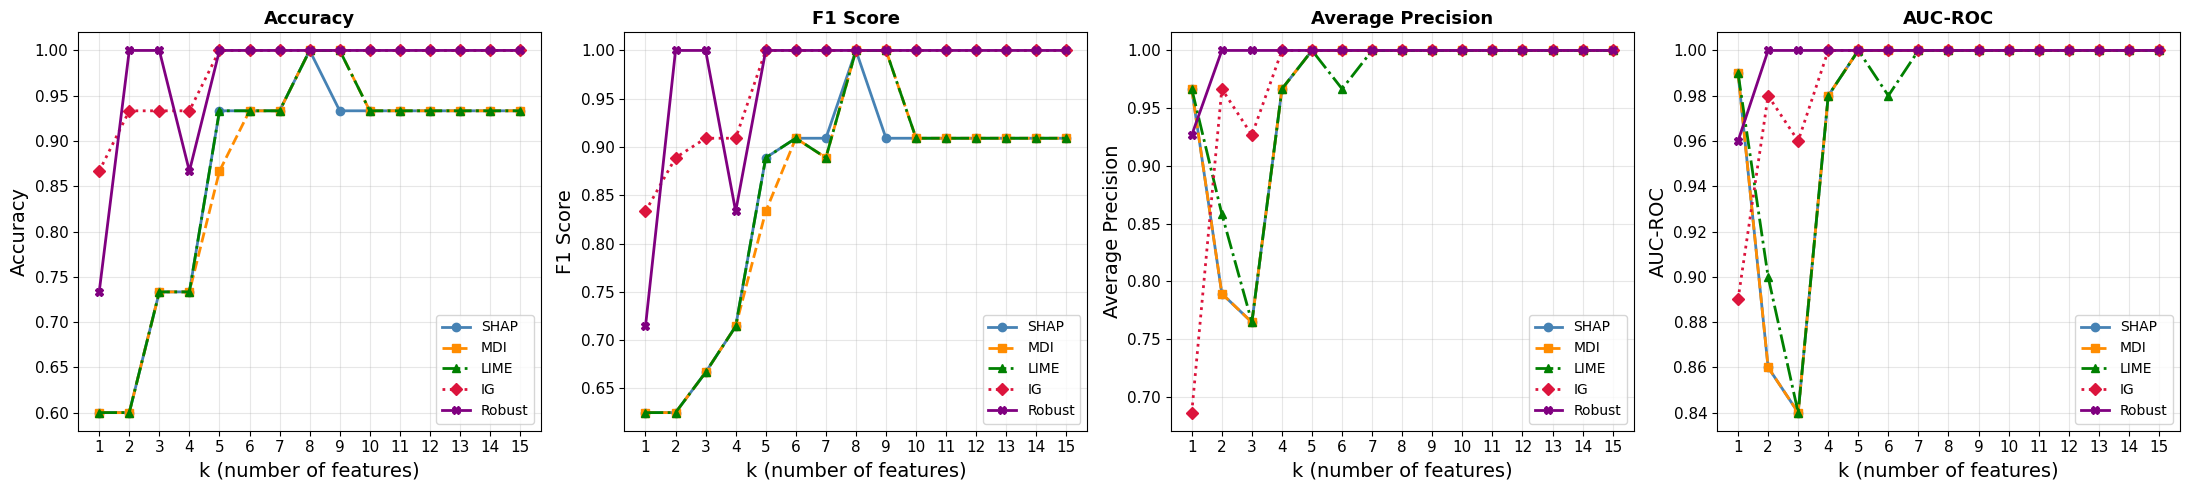

In [38]:
k_values = list(range(1, 16))

print('Evaluating RandomForest — SHAP...')
randomforest_res_shap = evaluate_topk(MODELS['RandomForest'], randomforest_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — MDI...')
randomforest_res_mdi = evaluate_topk(MODELS['RandomForest'], randomforest_gain, X_train, X_test, y_train, y_test, k_values) if randomforest_gain is not None else None

print('Evaluating RandomForest — LIME...')
randomforest_res_lime = evaluate_topk(MODELS['RandomForest'], randomforest_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — IG...')
randomforest_res_ig = evaluate_topk(MODELS['RandomForest'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — Robust Bootstrap...')
randomforest_res_robust = evaluate_topk(MODELS['RandomForest'], rf_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'MDI': randomforest_res_mdi,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'Robust': randomforest_res_robust},
    k_values,
)


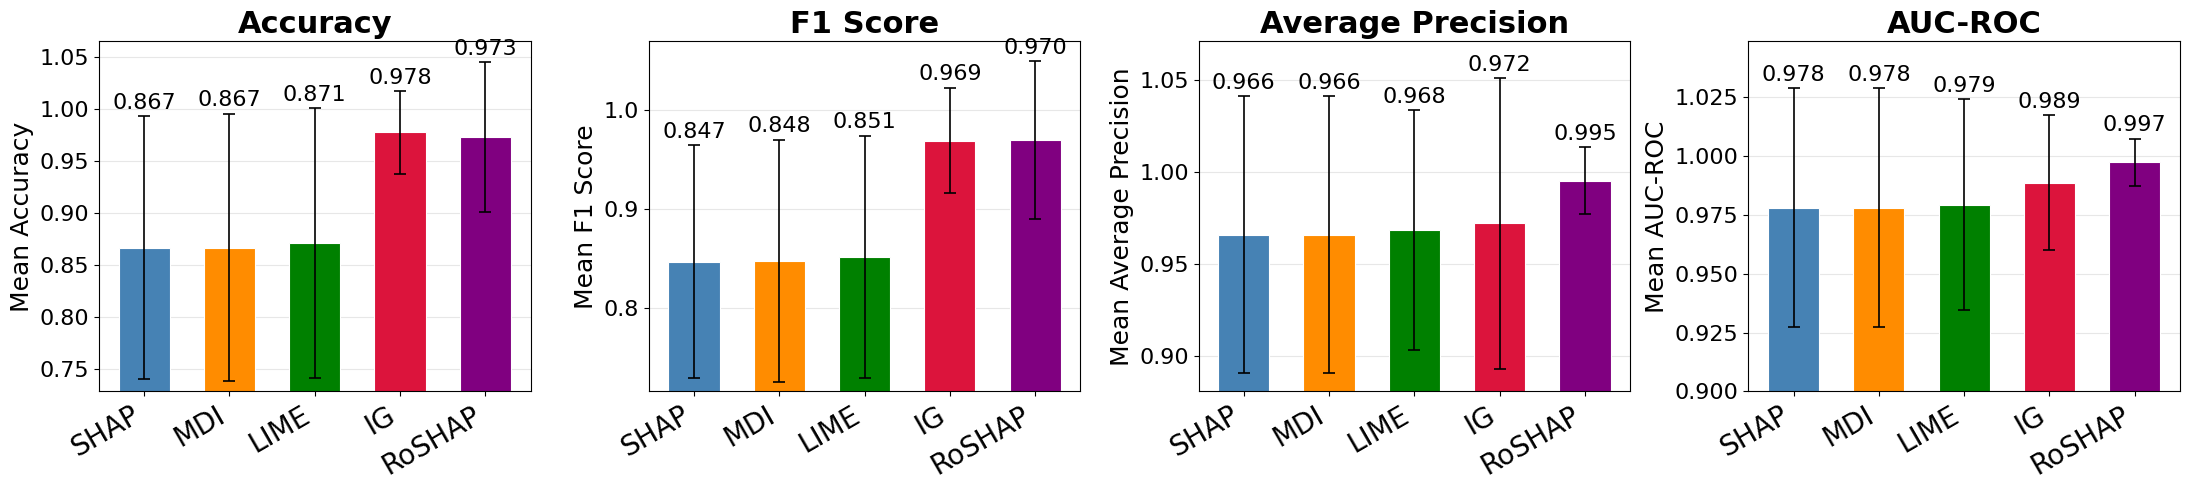

In [39]:
plot_comparison_bar(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'MDI': randomforest_res_mdi,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'RoSHAP': randomforest_res_robust},
    k_values,
)

---
## CatBoost

### CatBoost — SHAP

In [40]:
print('Computing SHAP ranking for CatBoost...')
catboost_shap = get_shap_ranking(MODELS['CatBoost'], X_train, y_train)
print('Top-10:')
catboost_shap.head(10)

Computing SHAP ranking for CatBoost...
Top-10:


,feature,importance
0,M31523_at,20.273657
1,L09209_s_at,18.899044
2,J05243_at,15.853832
3,M27891_at,10.696365
4,X95735_at,10.212754
5,U46499_at,8.561955
6,M23197_at,7.355754
7,M11722_at,5.381562
8,M92287_at,4.862987
9,M31211_s_at,4.341259


### CatBoost — Gain

In [41]:
print('Computing Gain ranking for CatBoost...')
catboost_gain = get_gain_ranking(MODELS['CatBoost'], X_train, y_train)
if catboost_gain is not None:
    print('Top-10:')
    display(catboost_gain.head(10))
else:
    print('Gain not supported for CatBoost')


Computing Gain ranking for CatBoost...
Top-10:


,feature,importance
0,M31523_at,9.741786
1,L09209_s_at,7.360089
2,J05243_at,7.256967
3,M27891_at,6.357742
4,U46499_at,6.297118
5,X95735_at,5.816374
6,M11722_at,3.870788
7,M23197_at,3.293283
8,M92287_at,2.563789
9,M83667_rna1_s_at,2.302158


### CatBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [42]:
print('Computing LIME ranking for CatBoost...')
catboost_lime = get_lime_ranking(
    MODELS['CatBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
catboost_lime.head(10)


Computing LIME ranking for CatBoost...
Top-10:


,feature,importance
0,L09209_s_at,0.071384
1,J05243_at,0.070258
2,M31523_at,0.055844
3,X95735_at,0.039205
4,U46499_at,0.031783
5,M27891_at,0.031736
6,M23197_at,0.015903
7,M11722_at,0.012522
8,M92287_at,0.007076
9,D88422_at,0.006759


### CatBoost — Robust

In [29]:
# first50 = catboost_shap['feature'].head(50).tolist()

In [41]:
cb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=cb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 1/1000 [00:39<10:50:42, 39.08s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   0%|          | 4/1000 [00:41<1:49:37,  6.60s/it] /home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   0%|          | 5/1000 [00:44<1:27:33,  5.28s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can

In [43]:
filepath = shap_path+"/xgb_cb.parquet"
# pd.concat(cb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath,
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
cb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(cb_boot_unscreen)} bootstrap results")

Loaded 1000 bootstrap results


In [44]:
cb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [45]:
tmp = cb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

catboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
catboost_robust.head(10)


,feature,importance
Rank,,
1,M31523_at,2.454055
2,L09209_s_at,1.915125
3,J05243_at,1.479698
4,M27891_at,0.724035
5,X95735_at,0.666975
6,M23197_at,0.613934
7,U46499_at,0.597122
8,M84526_at,0.487300
9,X62320_at,0.118043


### CatBoost — Evaluation & Comparison

Evaluating CatBoost — SHAP...
Evaluating CatBoost — Native...
Evaluating CatBoost — LIME...
Evaluating CatBoost — IG...
Evaluating CatBoost — Robust Bootstrap...


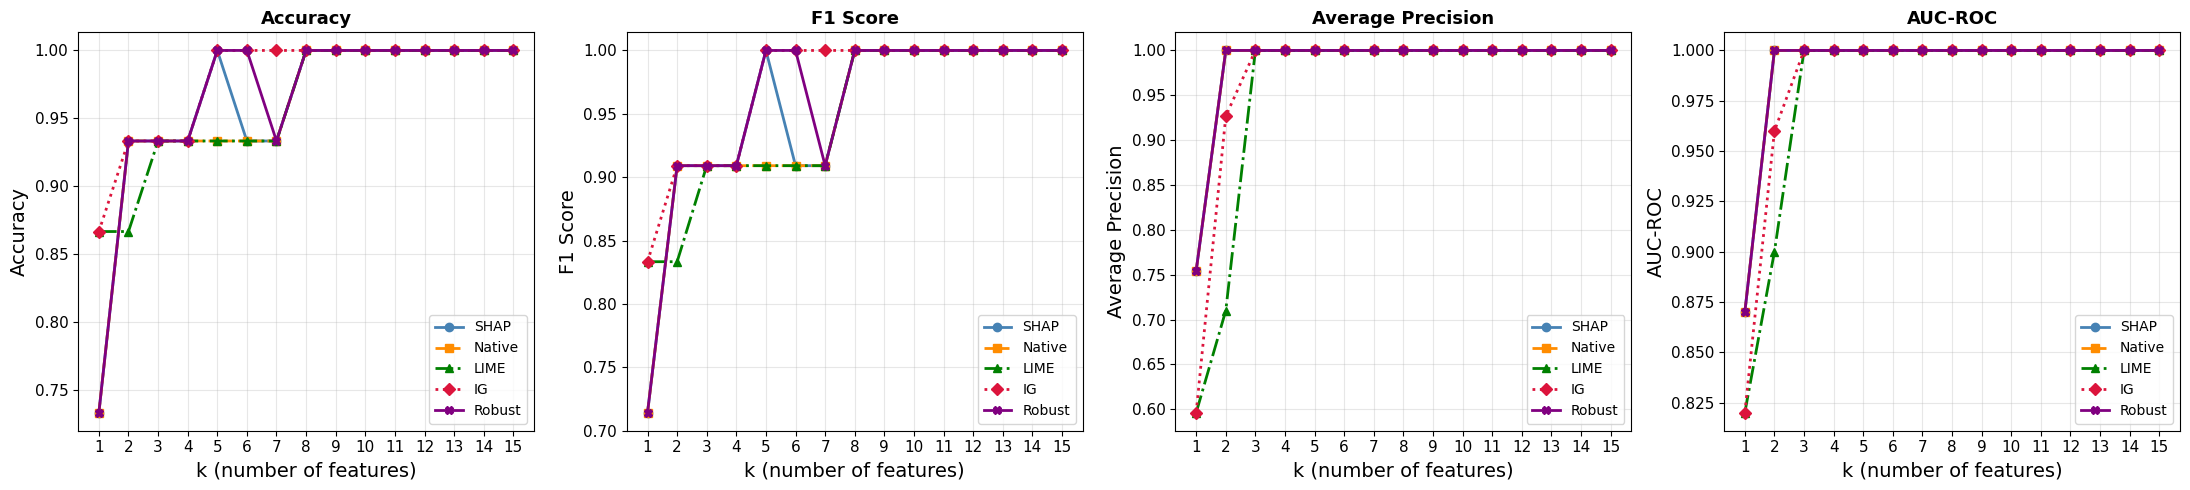

In [46]:
k_values = list(range(1, 16))

print('Evaluating CatBoost — SHAP...')
catboost_res_shap = evaluate_topk(MODELS['CatBoost'], catboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Native...')
catboost_res_native = evaluate_topk(MODELS['CatBoost'], catboost_gain, X_train, X_test, y_train, y_test, k_values) if catboost_gain is not None else None

print('Evaluating CatBoost — LIME...')
catboost_res_lime = evaluate_topk(MODELS['CatBoost'], catboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — IG...')
catboost_res_ig = evaluate_topk(MODELS['CatBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Robust Bootstrap...')
catboost_res_robust = evaluate_topk(MODELS['CatBoost'], catboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Native': catboost_res_native,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'Robust': catboost_res_robust},
    k_values,
)


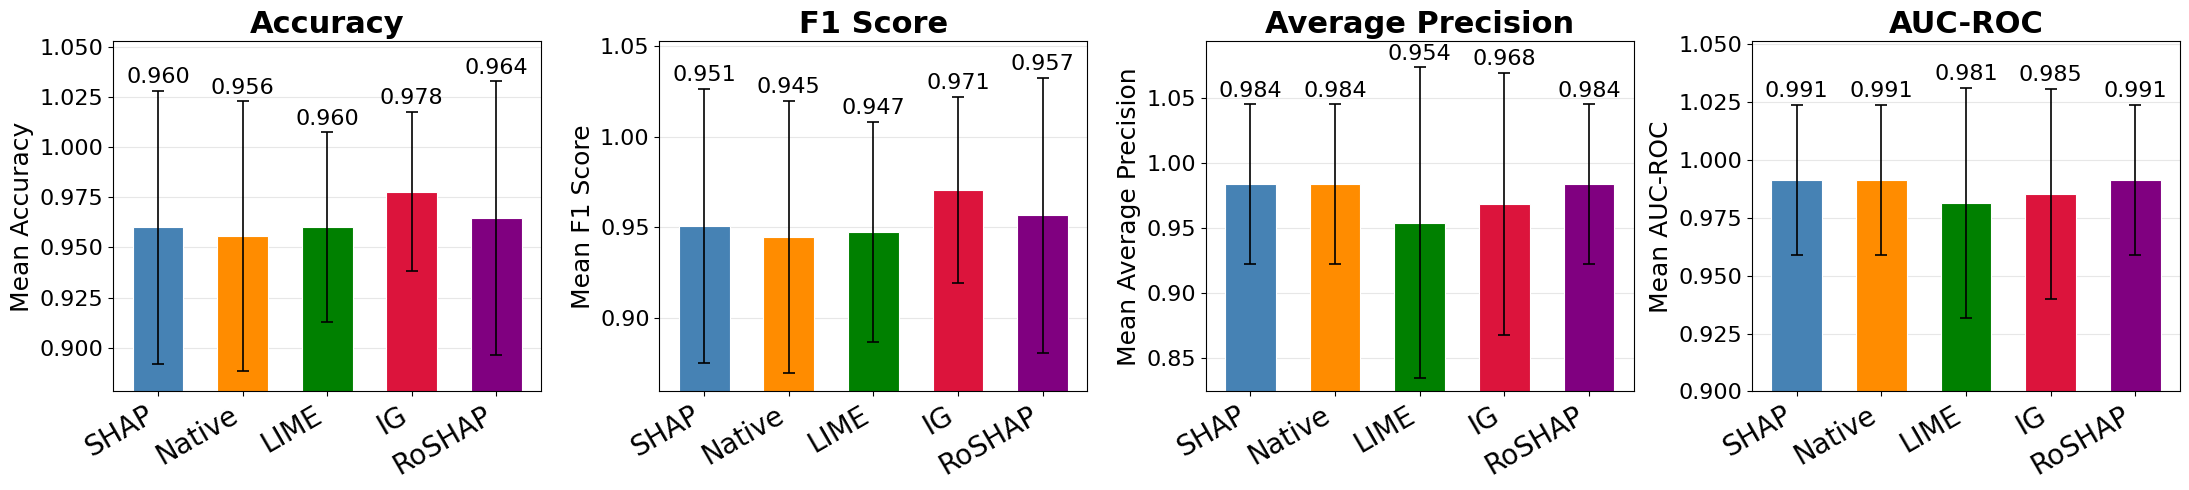

In [47]:
plot_comparison_bar(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Native': catboost_res_native,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'RoSHAP': catboost_res_robust},
    k_values,
)

---
## GradientBoosting

### GradientBoosting — SHAP

In [62]:
print('Computing SHAP ranking for GradientBoosting...')
gradientboosting_shap = get_shap_ranking(MODELS['GradientBoosting'], X_train, y_train)
print('Top-10:')
gradientboosting_shap.head(10)

Computing SHAP ranking for GradientBoosting...
Top-10:


,feature,importance
0,M62762_at,12.474110
1,M31523_at,12.195514
2,L09209_s_at,11.669965
3,M83652_s_at,11.630864
4,M92287_at,9.156550
5,D88270_at,9.101878
6,M83667_rna1_s_at,8.959223
7,X95735_at,8.067129
8,M55150_at,7.751609
9,U29175_at,7.542058


### GradientBoosting — Gain

In [63]:
print('Computing Gain ranking for GradientBoosting...')
gradientboosting_gain = get_gain_ranking(MODELS['GradientBoosting'], X_train, y_train)
if gradientboosting_gain is not None:
    print('Top-10:')
    display(gradientboosting_gain.head(10))
else:
    print('Gain not supported for GradientBoosting')


Computing Gain ranking for GradientBoosting...
Top-10:


,feature,importance
0,X62320_at,0.061211
1,X82240_rna1_at,0.055328
2,M62762_at,0.054749
3,L09209_s_at,0.052617
4,L19437_at,0.046074
5,D88270_at,0.035272
6,X85116_rna1_s_at,0.032008
7,J04449_at,0.023674
8,M12959_s_at,0.020351
9,X05908_at,0.020056


### GradientBoosting — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [64]:
print('Computing LIME ranking for GradientBoosting...')
gradientboosting_lime = get_lime_ranking(
    MODELS['GradientBoosting'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
gradientboosting_lime.head(10)

Computing LIME ranking for GradientBoosting...
Top-10:


,feature,importance
0,D88270_at,0.008907
1,L09209_s_at,0.008782
2,M62762_at,0.008667
3,M83652_s_at,0.005964
4,M31523_at,0.005831
5,M83667_rna1_s_at,0.004516
6,M55150_at,0.004506
7,X62320_at,0.004447
8,U46499_at,0.003995
9,D26156_s_at,0.003767


### GradientBoosting — Robust

In [65]:
# first50 = gradientboosting_shap['feature'].head(50).tolist()

In [49]:
gb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=gb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [01:42<00:00,  4.86it/s]


In [66]:
filepath = shap_path+"/gb_golub.parquet"
# pd.concat(gb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath,
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
gb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(gb_boot_unscreen)} bootstrap results")

Loaded 500 bootstrap results


In [67]:
gb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=gb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [68]:
tmp = gb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

gradientboosting_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
gradientboosting_robust.head(10)


,feature,importance
Rank,,
1,L09209_s_at,4.035586
2,M31523_at,3.975518
3,J05243_at,3.275916
4,X95735_at,3.186287
5,M23197_at,2.722039
6,U46499_at,2.470524
7,M27891_at,2.446405
8,M92287_at,2.401152
9,X62654_rna1_at,2.312872


### GradientBoosting — Evaluation & Comparison

Evaluating GradientBoosting — SHAP...
Evaluating GradientBoosting — MDI...
Evaluating GradientBoosting — LIME...
Evaluating GradientBoosting — IG...
Evaluating GradientBoosting — Robust Bootstrap...


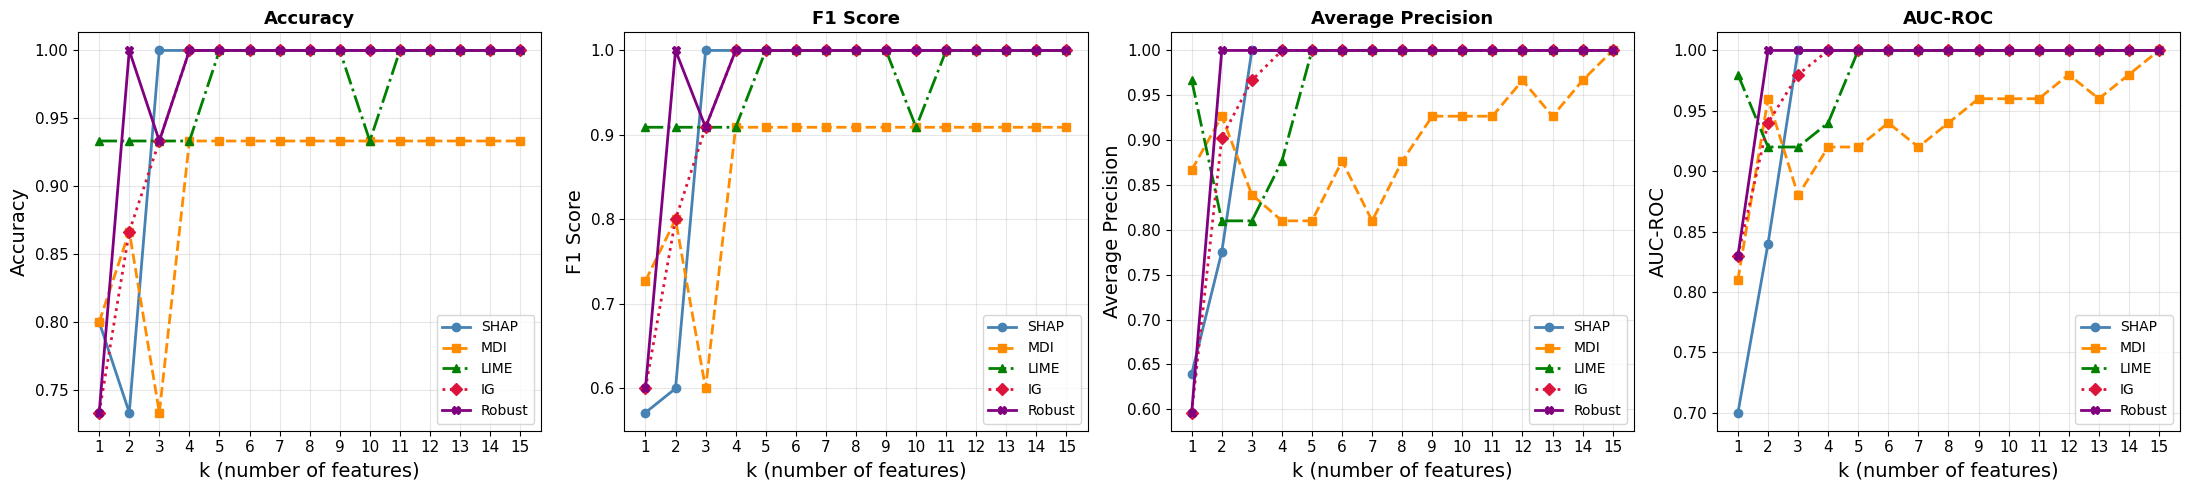

In [69]:
k_values = list(range(1, 16))

print('Evaluating GradientBoosting — SHAP...')
gradientboosting_res_shap = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — MDI...')
gradientboosting_res_mdi = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_gain, X_train, X_test, y_train, y_test, k_values) if gradientboosting_gain is not None else None

print('Evaluating GradientBoosting — LIME...')
gradientboosting_res_lime = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — IG...')
gradientboosting_res_ig = evaluate_topk(MODELS['GradientBoosting'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — Robust Bootstrap...')
gradientboosting_res_robust = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'MDI': gradientboosting_res_mdi,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'Robust': gradientboosting_res_robust},
    k_values,
)


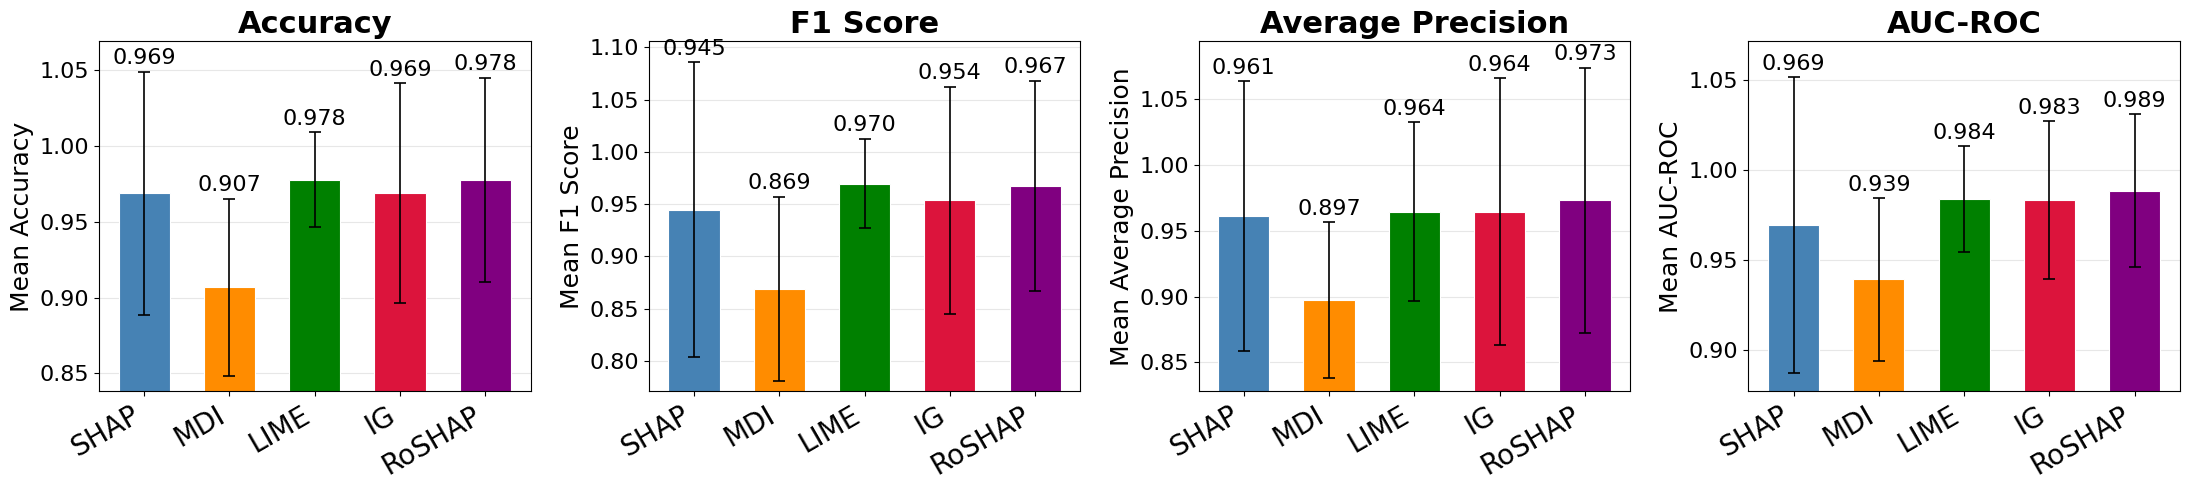

In [70]:
plot_comparison_bar(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'MDI': gradientboosting_res_mdi,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'RoSHAP': gradientboosting_res_robust},
    k_values,
)

---
## LogisticRegression

### LogisticRegression — SHAP

In [53]:
print('Computing SHAP ranking for LogisticRegression...')
logisticregression_shap = get_shap_ranking(MODELS['LogisticRegression'], X_train, y_train)
print('Top-10:')
logisticregression_shap.head(10)

Computing SHAP ranking for LogisticRegression...
Top-10:


,feature,importance
0,Y07604_at,1.093295
1,M26708_s_at,1.071592
2,M65214_s_at,1.070790
3,M84371_rna1_s_at,1.065473
4,X95735_at,1.017144
5,X17042_at,1.014492
6,J05243_at,0.977268
7,L09209_s_at,0.966181
8,U46499_at,0.964447
9,M93056_at,0.956847


### LogisticRegression — Gain

In [54]:
print('Computing Gain ranking for LogisticRegression...')
logisticregression_gain = get_gain_ranking(MODELS['LogisticRegression'], X_train, y_train)
if logisticregression_gain is not None:
    print('Top-10:')
    display(logisticregression_gain.head(10))
else:
    print('Gain not supported for LogisticRegression')


Computing Gain ranking for LogisticRegression...
Top-10:


,feature,importance
0,Y07604_at,0.023682
1,M65214_s_at,0.022954
2,U46499_at,0.022814
3,M26708_s_at,0.022689
4,U59632_s_at,0.022577
5,M34344_at,0.022495
6,L09209_s_at,0.022122
7,M96326_rna1_at,0.021981
8,J05243_at,0.021783
9,D29643_at,0.021685


### LogisticRegression — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [55]:
print('Computing LIME ranking for LogisticRegression...')
logisticregression_lime = get_lime_ranking(
    MODELS['LogisticRegression'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
logisticregression_lime.head(10)


Computing LIME ranking for LogisticRegression...
Top-10:


,feature,importance
0,M62762_at,0.002629
1,M84332_at,0.002469
2,L08096_s_at,0.002404
3,D49950_at,0.002053
4,U49278_at,0.001947
5,X65644_at,0.001945
6,U82313_at,0.001845
7,S68805_at,0.001749
8,M34344_at,0.001729
9,X95735_at,0.001727


### LogisticRegression — Robust

In [56]:
# first50 = logisticregression_shap['feature'].head(50).tolist()

In [59]:
lr_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lr_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   6%|▌         | 57/1000 [00:32<06:16,  2.50it/s] 

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [07:14<00:00,  2.30it/s]


In [57]:
filepath = shap_path+"/lr_golub.parquet"
# pd.concat(lr_boot_unscreen, ignore_index=True).to_parquet(
#     filepath,
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
lr_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(lr_boot_unscreen)} bootstrap results")

Loaded 1000 bootstrap results


In [58]:
lr_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lr_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [59]:
tmp = lr_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

logisticregression_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
logisticregression_robust.head(10)


,feature,importance
Rank,,
1,X95735_at,1.279244
2,M93056_at,1.184384
3,Y07604_at,1.168869
4,M84371_rna1_s_at,1.165508
5,X17042_at,1.161157
6,L09209_s_at,1.077786
7,L11669_at,1.066493
8,M65214_s_at,1.054190
9,M26708_s_at,1.040375


### LogisticRegression — Evaluation & Comparison

Evaluating LogisticRegression — SHAP...
Evaluating LogisticRegression — |Coef|...
Evaluating LogisticRegression — LIME...
Evaluating LogisticRegression — IG...
Evaluating LogisticRegression — Robust Bootstrap...


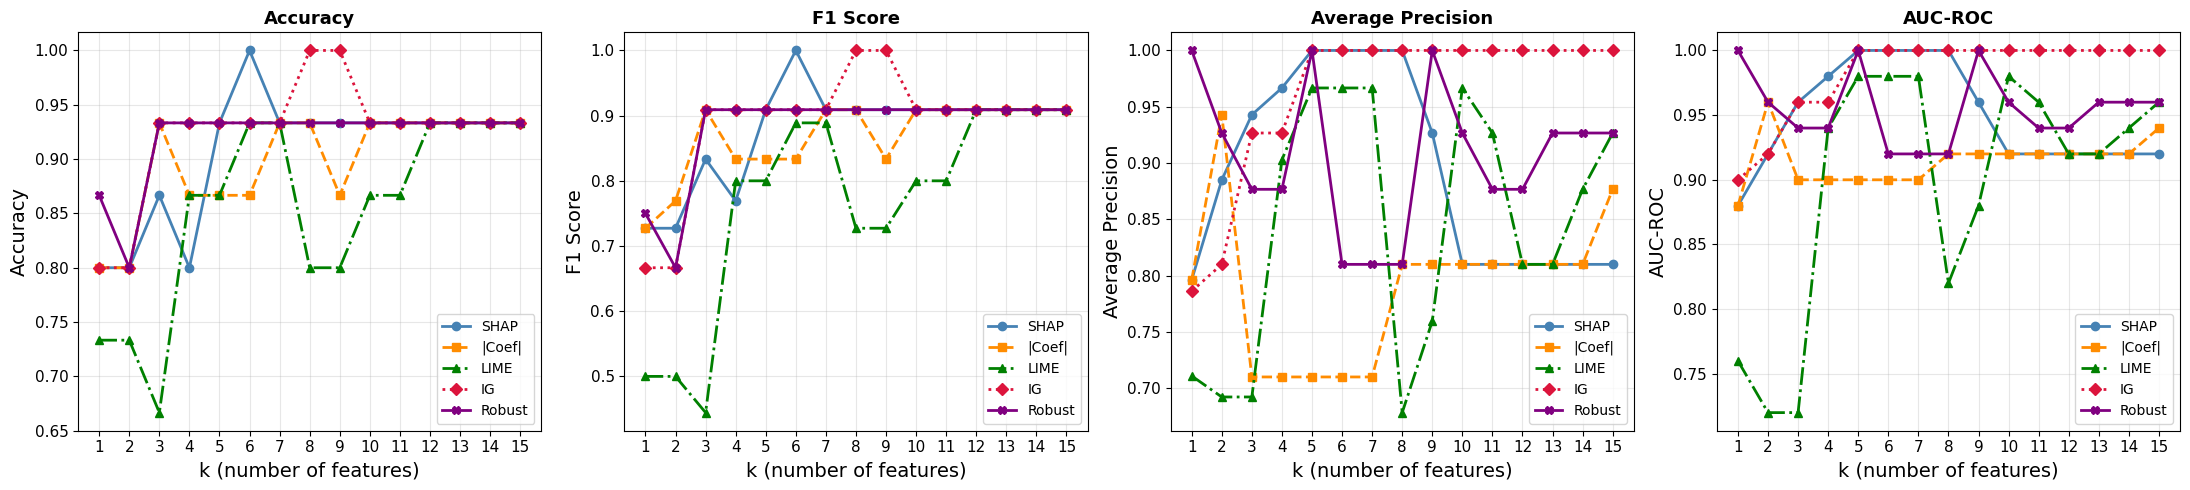

In [60]:
k_values = list(range(1, 16))

print('Evaluating LogisticRegression — SHAP...')
logisticregression_res_shap = evaluate_topk(MODELS['LogisticRegression'], logisticregression_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — |Coef|...')
logisticregression_res_coef = evaluate_topk(MODELS['LogisticRegression'], logisticregression_gain, X_train, X_test, y_train, y_test, k_values) if logisticregression_gain is not None else None

print('Evaluating LogisticRegression — LIME...')
logisticregression_res_lime = evaluate_topk(MODELS['LogisticRegression'], logisticregression_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — IG...')
logisticregression_res_ig = evaluate_topk(MODELS['LogisticRegression'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — Robust Bootstrap...')
logisticregression_res_robust = evaluate_topk(MODELS['LogisticRegression'], logisticregression_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'LogisticRegression',
    {'SHAP': logisticregression_res_shap, '|Coef|': logisticregression_res_coef,
     'LIME': logisticregression_res_lime, 'IG':   logisticregression_res_ig, 'Robust': logisticregression_res_robust},
    k_values,
)


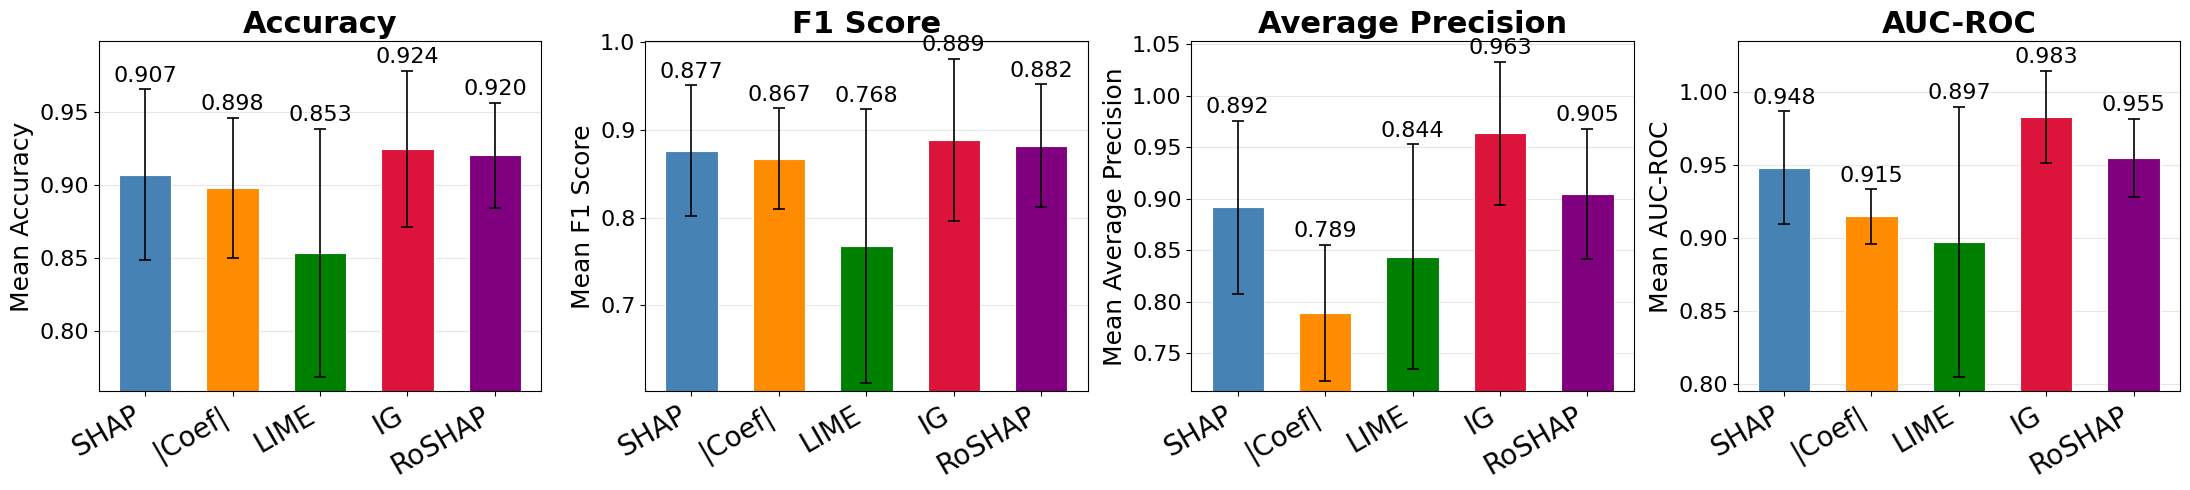

In [61]:
plot_comparison_bar(
    'LogisticRegression',
    {'SHAP': logisticregression_res_shap, '|Coef|': logisticregression_res_coef,
     'LIME': logisticregression_res_lime, 'IG':   logisticregression_res_ig, 'RoSHAP': logisticregression_res_robust},
    k_values,
)